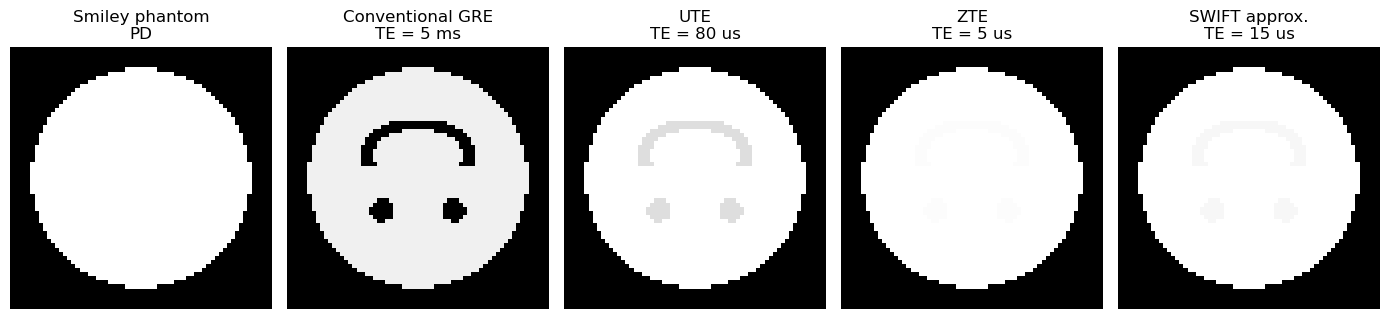

Mean signal:
Conventional GRE TE = 5 ms
  long T2 signal : 0.93936604468686
  short T2 signal: 1.891977343545364e-05
  short/long     : 2.0141002053955007e-05
UTE TE = 80 us
  long T2 signal : 0.9989504993236938
  short T2 signal: 0.06888595490447146
  short/long     : 0.06895832671499579
ZTE TE = 5 us
  long T2 signal : 0.9998999532172448
  short T2 signal: 0.07818821840092535
  short/long     : 0.07819604166331796
SWIFT approx. TE = 15 us
  long T2 signal : 0.9997499794725738
  short T2 signal: 0.07663998794480587
  short/long     : 0.07665915430699774


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from bloch.bloch import bloch
from bloch.viz import visualize_magnetization_anim

# assumes your bloch() function is already imported/defined


# -----------------------------
# 1. Smiley phantom
# -----------------------------
def make_smiley_phantom(N=64):
    y, x = np.mgrid[-1:1:complex(N), -1:1:complex(N)]

    rho = np.zeros((N, N))
    T1 = np.ones((N, N)) * 1.0
    T2 = np.ones((N, N)) * 1e-3

    head = x**2 + y**2 <= 0.85**2
    rho[head] = 1.0
    T1[head] = 1.0
    T2[head] = 80e-3       # long T2 tissue, 80 ms

    eye1 = (x + 0.28)**2 + (y - 0.25)**2 <= 0.09**2
    eye2 = (x - 0.28)**2 + (y - 0.25)**2 <= 0.09**2
    eyes = eye1 | eye2

    mouth_outer = ((x / 0.45)**2 + ((y + 0.18) / 0.28)**2 <= 1) & (y < -0.1)
    mouth_inner = ((x / 0.34)**2 + ((y + 0.18) / 0.20)**2 <= 1) & (y < -0.1)
    mouth = mouth_outer & ~mouth_inner

    short_t2 = eyes | mouth
    rho[short_t2] = 1.0
    T1[short_t2] = 0.8
    T2[short_t2] = 0.6e-3  # short T2 tissue, 0.6 ms

    return rho, T1, T2


# -----------------------------
# 2. Hard RF pulse creator
# -----------------------------
def hard_pulse(flip_deg=90, dt=4e-6):
    """
    Creates one hard pulse sample.
    Approximation:
        flip = gamma_hz_per_g * B1 * duration * 360
    """
    gamma_hz_per_g = 4257
    flip_cycles = flip_deg / 360
    B1 = flip_cycles / (gamma_hz_per_g * dt)

    b1 = np.array([B1], dtype=np.complex128)
    gr = np.zeros((1, 1))
    tp = np.array([dt])
    return b1, gr, tp


# -----------------------------
# 3. Bloch simulate one method
# -----------------------------
def simulate_method(rho, T1map, T2map, TE, flip_deg=90):
    N = rho.shape[0]

    # Positions in cm
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, y)

    dp = np.vstack([
        X.ravel(),
        Y.ravel(),
        np.zeros(N * N)
    ])

    t1 = T1map.ravel()
    t2 = T2map.ravel()

    # One off-resonance frequency
    df = np.array([0])

    # Initial magnetization scaled by proton density
    mx0 = np.zeros((1, N * N))
    my0 = np.zeros((1, N * N))
    mz0 = rho.ravel()[None, :]

    # 90 degree excitation
    b1_rf, gr_rf, tp_rf = hard_pulse(flip_deg=flip_deg)

    mx, my, mz = bloch(
        b1=b1_rf,
        gr=gr_rf,
        tp=tp_rf,
        t1=t1,
        t2=t2,
        df=df,
        dp=dp,
        mode=0,
        mx=mx0,
        my=my0,
        mz=mz0
    )

    # Free decay until TE
    dt = 4e-6
    n_te = max(1, int(np.round(TE / dt)))

    b1_free = np.zeros(n_te, dtype=np.complex128)
    gr_free = np.zeros((1, n_te))
    tp_free = np.ones(n_te) * dt

    mx, my, mz = bloch(
        b1=b1_free,
        gr=gr_free,
        tp=tp_free,
        t1=t1,
        t2=t2,
        df=df,
        dp=dp,
        mode=0,
        mx=mx,
        my=my,
        mz=mz
    )

    img = mx.reshape(N, N) + 1j * my.reshape(N, N)
    return np.abs(img)


# -----------------------------
# 4. Run comparison
# -----------------------------
rho, T1map, T2map = make_smiley_phantom(N=64)

methods = {
    "Conventional GRE\nTE = 5 ms": 5e-3,
    "UTE\nTE = 80 us": 80e-6,
    "ZTE\nTE = 5 us": 5e-6,
    "SWIFT approx.\nTE = 15 us": 15e-6,
}

results = {}

for name, TE in methods.items():
    results[name] = simulate_method(
        rho=rho,
        T1map=T1map,
        T2map=T2map,
        TE=TE,
        flip_deg=90
    )


# -----------------------------
# 5. Plot results
# -----------------------------
plt.figure(figsize=(14, 4))

plt.subplot(1, 5, 1)
plt.imshow(rho, cmap="gray")
plt.title("Smiley phantom\nPD")
plt.axis("off")

for i, (name, img) in enumerate(results.items(), start=2):
    plt.subplot(1, 5, i)
    plt.imshow(img, cmap="gray", vmin=0, vmax=np.max(rho))
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()


# -----------------------------
# 6. Quantify short vs long T2 signal
# -----------------------------
short_mask = T2map < 5e-3
long_mask = T2map > 20e-3

print("Mean signal:")
for name, img in results.items():
    long_signal = img[long_mask].mean()
    short_signal = img[short_mask].mean()
    print(name.replace("\n", " "))
    print("  long T2 signal :", long_signal)
    print("  short T2 signal:", short_signal)
    print("  short/long     :", short_signal / long_signal)

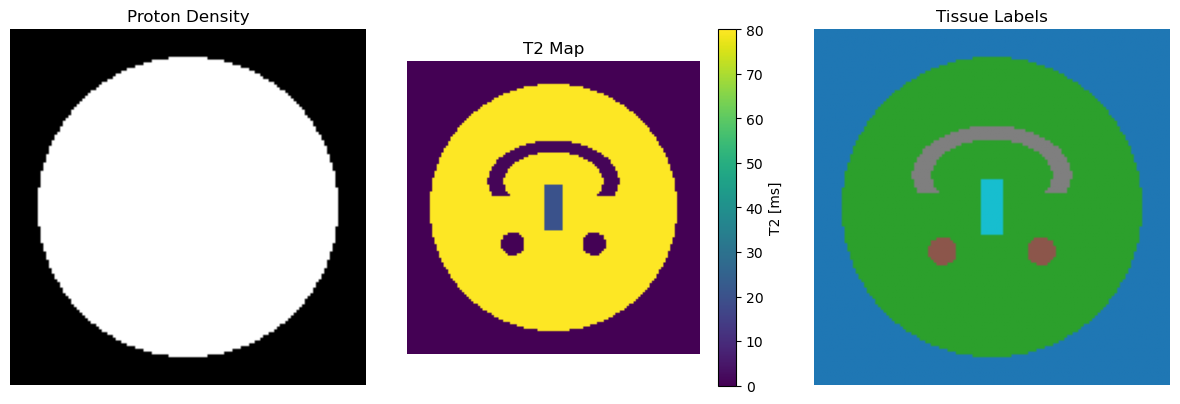

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def make_smiley_t2_phantom(
    N=128,
    T2_skin=80e-3,
    T2_eyes=0.6e-3,
    T2_mouth=1.0e-3,
    T2_nose=20e-3,
):
    y, x = np.mgrid[-1:1:complex(N), -1:1:complex(N)]

    # maps
    rho = np.zeros((N, N))      # proton density
    T2 = np.zeros((N, N))       # seconds
    labels = np.zeros((N, N))   # 0 background, 1 skin, 2 eyes, 3 mouth, 4 nose

    # face / skin
    skin = x**2 + y**2 <= 0.85**2
    rho[skin] = 1.0
    T2[skin] = T2_skin
    labels[skin] = 1

    # eyes
    left_eye = (x + 0.28)**2 + (y - 0.25)**2 <= 0.08**2
    right_eye = (x - 0.28)**2 + (y - 0.25)**2 <= 0.08**2
    eyes = left_eye | right_eye
    rho[eyes] = 1.0
    T2[eyes] = T2_eyes
    labels[eyes] = 2

    # nose
    nose = (
        (np.abs(x) < 0.07)
        & (y < 0.15)
        & (y > -0.15)
    )
    rho[nose] = 1.0
    T2[nose] = T2_nose
    labels[nose] = 4

    # mouth: crescent smile
    mouth_outer = (
        ((x / 0.45)**2 + ((y + 0.18) / 0.28)**2 <= 1)
        & (y < -0.08)
    )
    mouth_inner = (
        ((x / 0.34)**2 + ((y + 0.18) / 0.20)**2 <= 1)
        & (y < -0.08)
    )
    mouth = mouth_outer & ~mouth_inner

    rho[mouth] = 1.0
    T2[mouth] = T2_mouth
    labels[mouth] = 3

    return rho, T2, labels


# Example usage
rho, T2, labels = make_smiley_t2_phantom(
    N=128,
    T2_skin=80e-3,
    T2_eyes=0.6e-3,
    T2_mouth=1.0e-3,
    T2_nose=20e-3,
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rho, cmap="gray")
plt.title("Proton Density")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(T2 * 1e3, cmap="viridis")
plt.colorbar(label="T2 [ms]")
plt.title("T2 Map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(labels, cmap="tab10")
plt.title("Tissue Labels")
plt.axis("off")

plt.tight_layout()
plt.show()

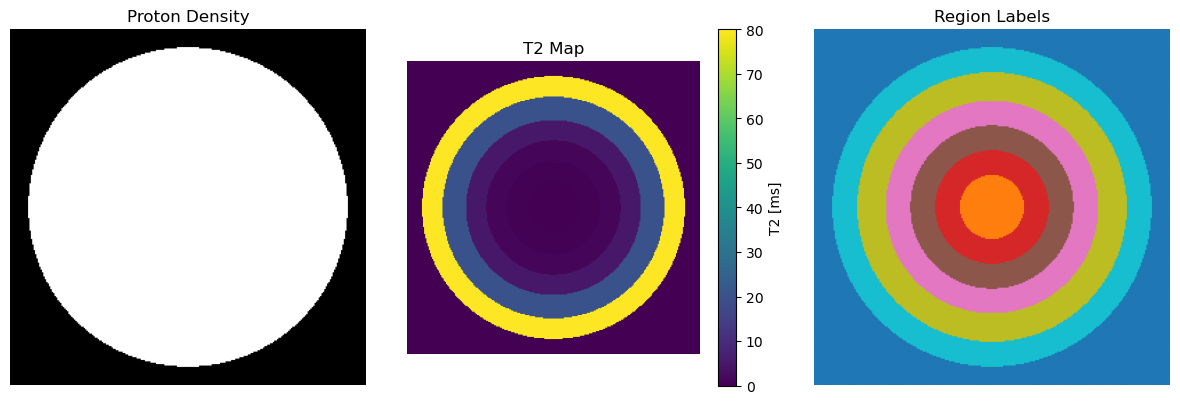

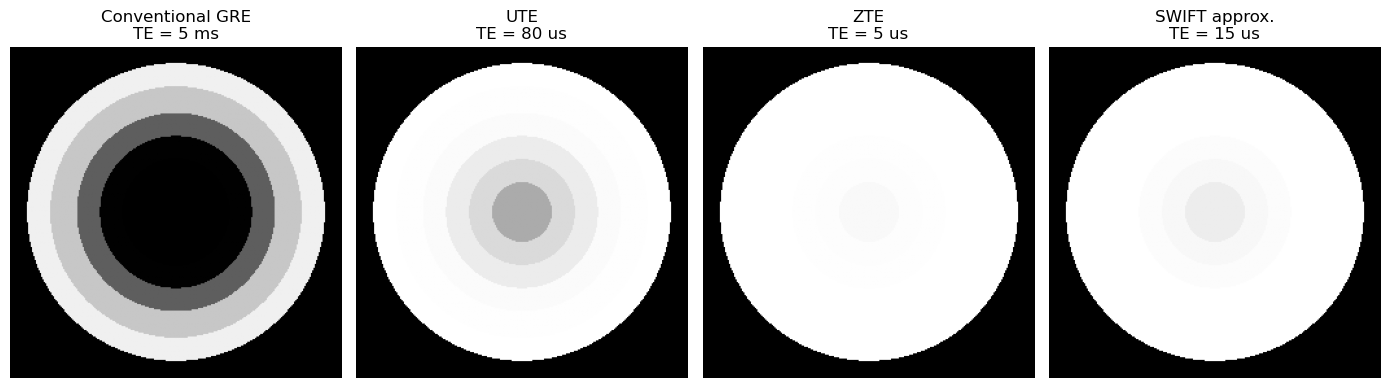

Ring-wise signal by method
--------------------------

Conventional GRE TE = 5 ms
  Region 1: T2 =   0.20 ms, signal = 0.0000
  Region 2: T2 =   0.50 ms, signal = 0.0000
  Region 3: T2 =   1.00 ms, signal = 0.0067
  Region 4: T2 =   5.00 ms, signal = 0.3679
  Region 5: T2 =  20.00 ms, signal = 0.7788
  Region 6: T2 =  80.00 ms, signal = 0.9394

UTE TE = 80 us
  Region 1: T2 =   0.20 ms, signal = 0.6703
  Region 2: T2 =   0.50 ms, signal = 0.8521
  Region 3: T2 =   1.00 ms, signal = 0.9231
  Region 4: T2 =   5.00 ms, signal = 0.9841
  Region 5: T2 =  20.00 ms, signal = 0.9960
  Region 6: T2 =  80.00 ms, signal = 0.9990

ZTE TE = 5 us
  Region 1: T2 =   0.20 ms, signal = 0.9753
  Region 2: T2 =   0.50 ms, signal = 0.9900
  Region 3: T2 =   1.00 ms, signal = 0.9950
  Region 4: T2 =   5.00 ms, signal = 0.9990
  Region 5: T2 =  20.00 ms, signal = 0.9998
  Region 6: T2 =  80.00 ms, signal = 0.9999

SWIFT approx. TE = 15 us
  Region 1: T2 =   0.20 ms, signal = 0.9277
  Region 2: T2 =   0.50 m

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def make_multit2_ring_phantom(N=128):
    """
    Returns:
        rho: proton density map
        T1:  T1 map in seconds
        T2:  T2 map in seconds
        labels: tissue-region labels
    """

    y, x = np.mgrid[-1:1:complex(N), -1:1:complex(N)]
    r = np.sqrt(x**2 + y**2)

    rho = np.zeros((N, N))
    T1 = np.zeros((N, N))
    T2 = np.zeros((N, N))
    labels = np.zeros((N, N))

    # Each region has different T2
    regions = [
        # r_min, r_max, rho, T1, T2, label
        (0.00, 0.18, 1.0, 0.8, 0.2e-3, 1),   # ultra-short T2
        (0.18, 0.32, 1.0, 0.8, 0.5e-3, 2),   # very short T2
        (0.32, 0.46, 1.0, 0.9, 1.0e-3, 3),   # short T2
        (0.46, 0.60, 1.0, 1.0, 5.0e-3, 4),   # intermediate T2
        (0.60, 0.76, 1.0, 1.2, 20e-3, 5),    # medium T2
        (0.76, 0.90, 1.0, 1.5, 80e-3, 6),    # long T2
    ]

    for rmin, rmax, pd, t1, t2, label in regions:
        mask = (r >= rmin) & (r < rmax)
        rho[mask] = pd
        T1[mask] = t1
        T2[mask] = t2
        labels[mask] = label

    return rho, T1, T2, labels


def simulate_TE_image(rho, T2, TE):
    """
    Simple signal model:
        S = rho * exp(-TE / T2)
    """
    img = np.zeros_like(rho)
    mask = T2 > 0
    img[mask] = rho[mask] * np.exp(-TE / T2[mask])
    return img


# -----------------------------
# Create phantom
# -----------------------------
rho, T1, T2, labels = make_multit2_ring_phantom(N=256)

# Example effective TEs
methods = {
    "Conventional GRE\nTE = 5 ms": 5e-3,
    "UTE\nTE = 80 us": 80e-6,
    "ZTE\nTE = 5 us": 5e-6,
    "SWIFT approx.\nTE = 15 us": 15e-6,
}

results = {}
for name, TE in methods.items():
    results[name] = simulate_TE_image(rho, T2, TE)


# -----------------------------
# Plot phantom maps
# -----------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rho, cmap="gray")
plt.title("Proton Density")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(T2 * 1e3, cmap="viridis")
plt.colorbar(label="T2 [ms]")
plt.title("T2 Map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(labels, cmap="tab10")
plt.title("Region Labels")
plt.axis("off")

plt.tight_layout()
plt.show()


# -----------------------------
# Plot method comparison
# -----------------------------
plt.figure(figsize=(14, 4))

for i, (name, img) in enumerate(results.items(), start=1):
    plt.subplot(1, 4, i)
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()


# -----------------------------
# Print ring-wise signal values
# -----------------------------
print("Ring-wise signal by method")
print("--------------------------")

for name, img in results.items():
    print("\n" + name.replace("\n", " "))
    for label in range(1, 7):
        mask = labels == label
        mean_signal = img[mask].mean()
        mean_T2_ms = T2[mask].mean() * 1e3
        print(f"  Region {label}: T2 = {mean_T2_ms:6.2f} ms, signal = {mean_signal:.4f}")

This version below uses radial sampling instead

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def radial_sample_and_recon(img, n_spokes=64, n_samples=256):
    """
    Educational radial MRI simulation:
    1. Convert image to Cartesian k-space
    2. Sample k-space along radial spokes
    3. Interpolate radial data back to Cartesian grid
    4. Reconstruct with inverse FFT
    """

    N = img.shape[0]

    # Cartesian k-space
    kspace = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))

    # Cartesian k-space coordinate grid
    k = np.linspace(-0.5, 0.5, N, endpoint=False)
    KX, KY = np.meshgrid(k, k)

    # Radial sampling coordinates
    angles = np.linspace(0, np.pi, n_spokes, endpoint=False)
    kr = np.linspace(-0.5, 0.5, n_samples)

    sample_kx = []
    sample_ky = []

    for theta in angles:
        sample_kx.append(kr * np.cos(theta))
        sample_ky.append(kr * np.sin(theta))

    sample_kx = np.concatenate(sample_kx)
    sample_ky = np.concatenate(sample_ky)

    # Interpolate Cartesian k-space onto radial locations
    radial_samples = griddata(
        points=(KX.ravel(), KY.ravel()),
        values=kspace.ravel(),
        xi=(sample_kx, sample_ky),
        method="linear",
        fill_value=0
    )

    # Grid radial samples back to Cartesian
    kspace_gridded = griddata(
        points=(sample_kx, sample_ky),
        values=radial_samples,
        xi=(KX, KY),
        method="linear",
        fill_value=0
    )

    # Reconstruct
    recon = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace_gridded)))
    recon = np.abs(recon)

    # Normalize
    recon /= recon.max() + 1e-12

    return recon, kspace, kspace_gridded, sample_kx, sample_ky

In [14]:
radial_results = {}

for name, img in results.items():
    recon, kspace, kspace_gridded, sample_kx, sample_ky = radial_sample_and_recon(
        img,
        n_spokes=64,
        n_samples=256
    )
    radial_results[name] = recon

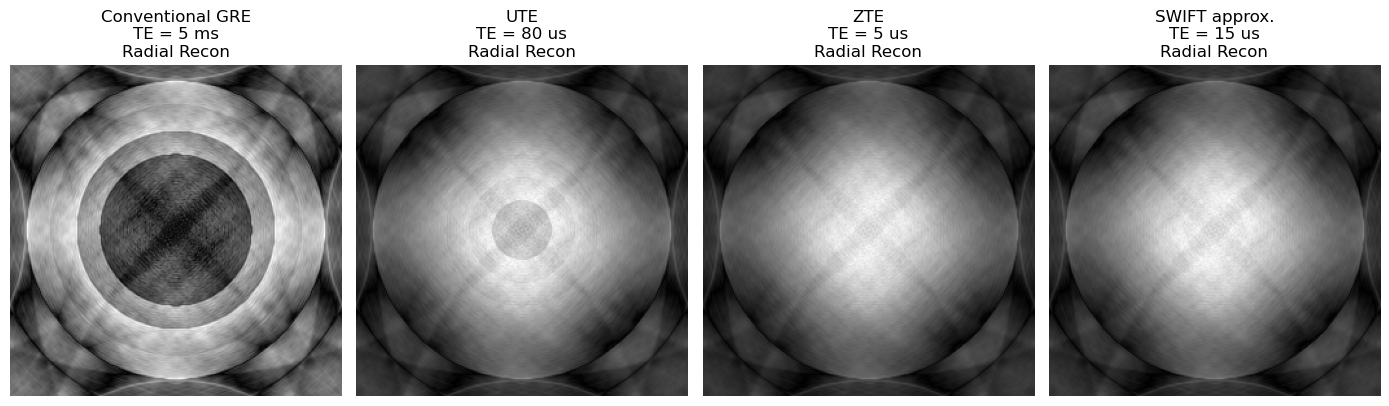

In [16]:
plt.figure(figsize=(14, 4))

for i, (name, img) in enumerate(radial_results.items(), start=1):
    plt.subplot(1, 4, i)
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title(name + "\nRadial Recon")
    plt.axis("off")

plt.tight_layout()
plt.show()

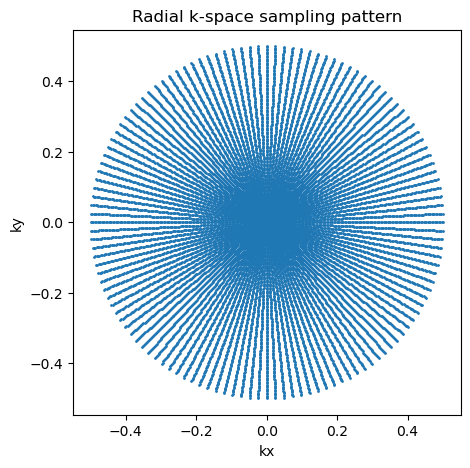

In [17]:
plt.figure(figsize=(5, 5))
plt.scatter(sample_kx, sample_ky, s=1)
plt.title("Radial k-space sampling pattern")
plt.xlabel("kx")
plt.ylabel("ky")
plt.axis("equal")
plt.show()

In [18]:
method_settings = {
    "UTE": {
        "TE": 80e-6,
        "n_spokes": 96
    },
    "ZTE": {
        "TE": 5e-6,
        "n_spokes": 160
    },
    "SWIFT": {
        "TE": 15e-6,
        "n_spokes": 128
    },
}

From here below we use spiral trajectories through k-space

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def spiral_sample_and_recon(img, n_interleaves=16, n_samples=2048, n_turns=8):
    """
    Educational spiral MRI simulation:
    1. Convert image to Cartesian k-space
    2. Sample k-space along spiral interleaves
    3. Grid spiral samples back to Cartesian k-space
    4. Reconstruct with inverse FFT
    """

    N = img.shape[0]

    # Cartesian k-space
    kspace = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))

    # Cartesian k-space coordinate grid
    k = np.linspace(-0.5, 0.5, N, endpoint=False)
    KX, KY = np.meshgrid(k, k)

    sample_kx = []
    sample_ky = []

    t = np.linspace(0, 1, n_samples)
    r = 0.5 * t
    theta = 2 * np.pi * n_turns * t

    for i in range(n_interleaves):
        angle_offset = 2 * np.pi * i / n_interleaves

        kx = r * np.cos(theta + angle_offset)
        ky = r * np.sin(theta + angle_offset)

        sample_kx.append(kx)
        sample_ky.append(ky)

    sample_kx = np.concatenate(sample_kx)
    sample_ky = np.concatenate(sample_ky)

    # Sample Cartesian k-space at spiral locations
    spiral_samples = griddata(
        points=(KX.ravel(), KY.ravel()),
        values=kspace.ravel(),
        xi=(sample_kx, sample_ky),
        method="linear",
        fill_value=0
    )

    # Grid spiral data back to Cartesian
    kspace_gridded = griddata(
        points=(sample_kx, sample_ky),
        values=spiral_samples,
        xi=(KX, KY),
        method="linear",
        fill_value=0
    )

    # Reconstruct
    recon = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace_gridded)))
    recon = np.abs(recon)
    recon /= recon.max() + 1e-12

    return recon, kspace, kspace_gridded, sample_kx, sample_ky

In [25]:
spiral_results = {}

for name, img in results.items():
    recon, kspace, kspace_gridded, sample_kx, sample_ky = spiral_sample_and_recon(
        img,
        n_interleaves=24,
        n_samples=2048,
        n_turns=8
    )
    spiral_results[name] = recon

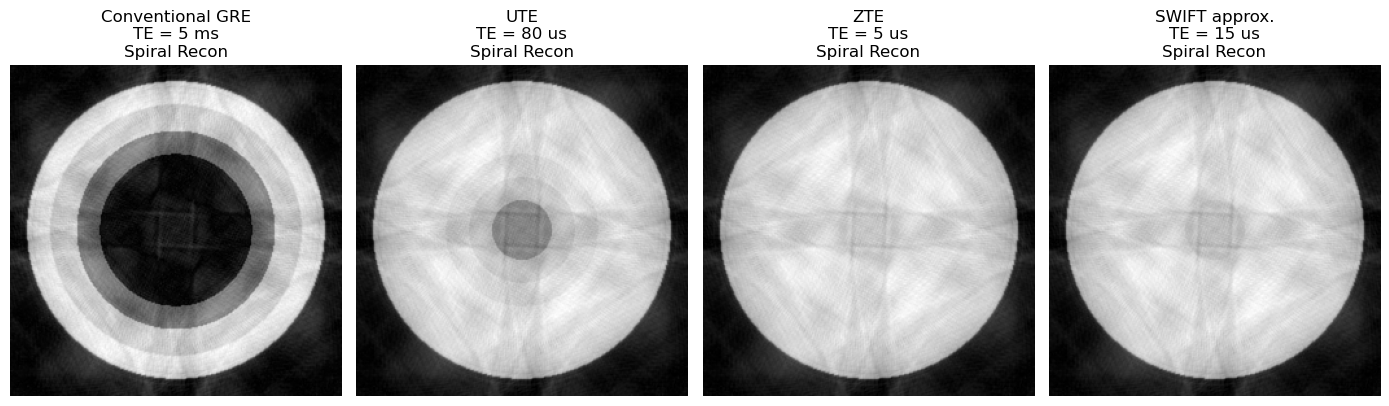

In [26]:
plt.figure(figsize=(14, 4))

for i, (name, img) in enumerate(spiral_results.items(), start=1):
    plt.subplot(1, 4, i)
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title(name + "\nSpiral Recon")
    plt.axis("off")

plt.tight_layout()
plt.show()

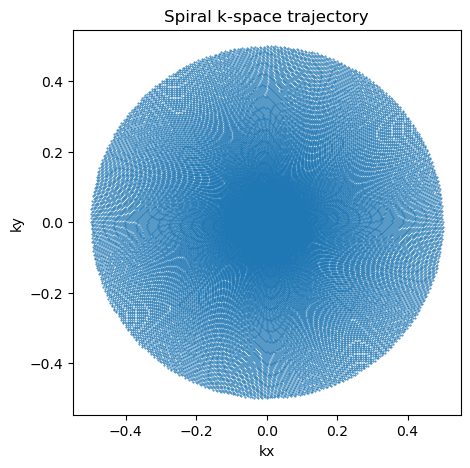

In [27]:
plt.figure(figsize=(5, 5))
plt.scatter(sample_kx, sample_ky, s=0.2)
plt.title("Spiral k-space trajectory")
plt.xlabel("kx")
plt.ylabel("ky")
plt.axis("equal")
plt.show()

In [28]:
trajectory_settings = {
    "UTE spiral": {
        "TE": 80e-6,
        "n_interleaves": 24,
        "n_turns": 8,
    },
    "ZTE radial-like": {
        "TE": 5e-6,
        "n_interleaves": 32,
        "n_turns": 1,
    },
    "SWIFT spiral-like": {
        "TE": 15e-6,
        "n_interleaves": 32,
        "n_turns": 10,
    },
}

Gonna bring back the smileyface

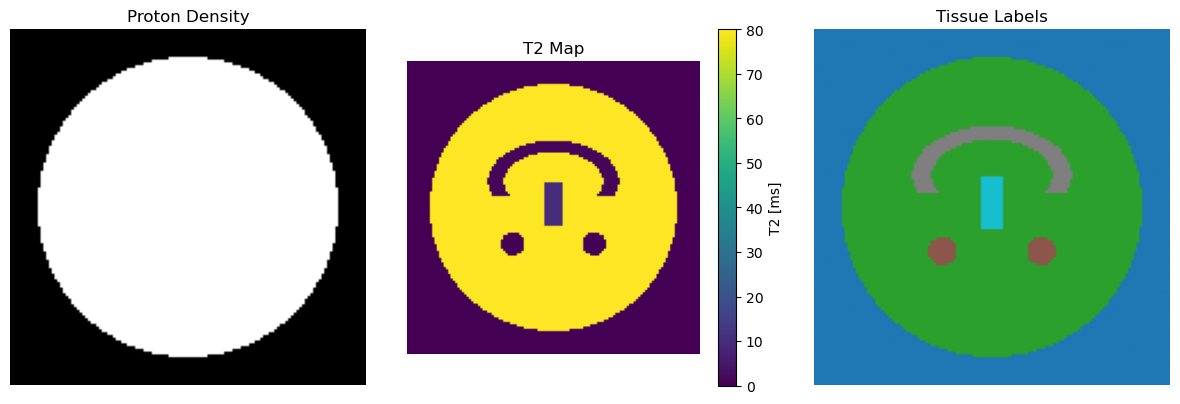

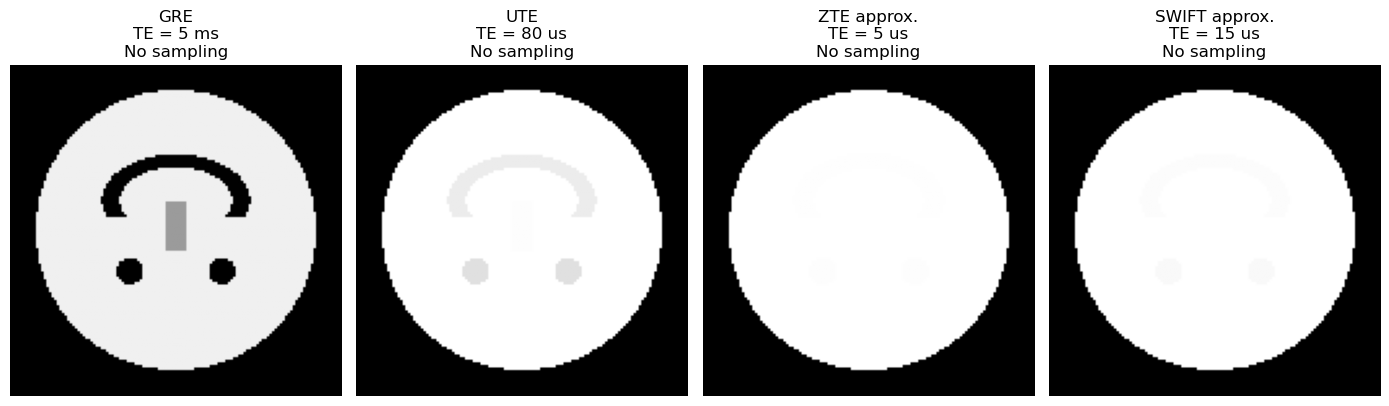

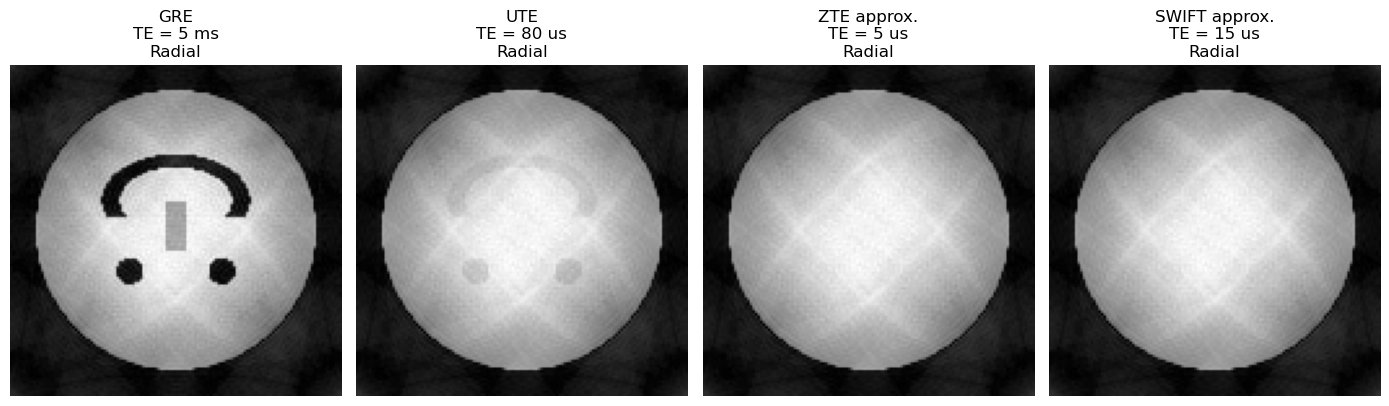

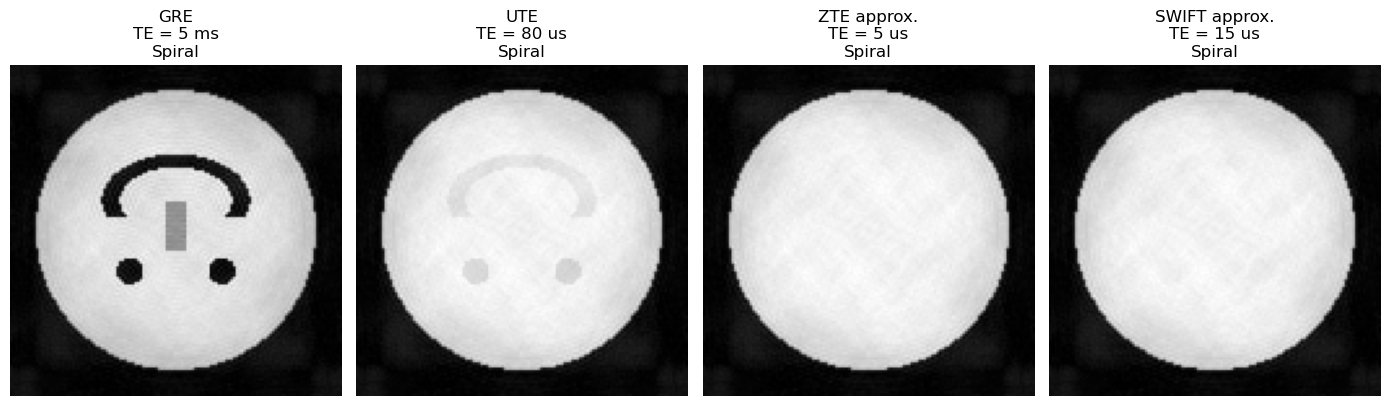

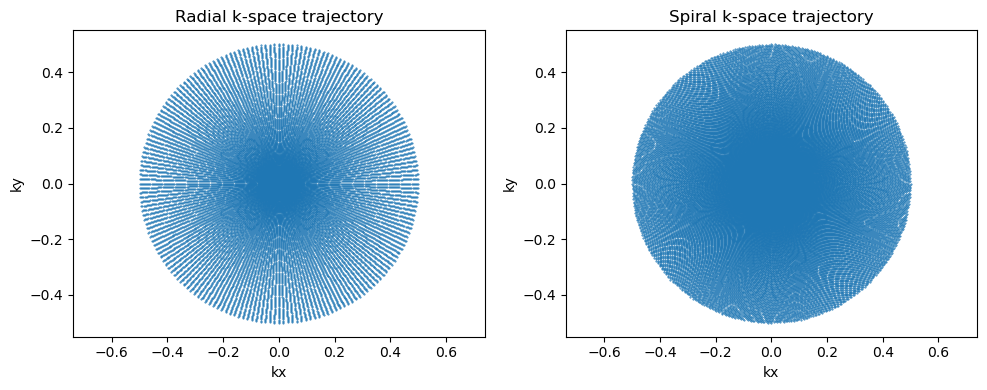

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata


# -----------------------------
# 1. Smiley T2 phantom
# -----------------------------
def make_smiley_t2_phantom(
    N=128,
    T2_skin=80e-3,
    T2_eyes=0.6e-3,
    T2_mouth=1.0e-3,
    T2_nose=10e-3,
):
    y, x = np.mgrid[-1:1:complex(N), -1:1:complex(N)]

    rho = np.zeros((N, N))
    T2 = np.zeros((N, N))
    labels = np.zeros((N, N))

    # face / skin
    skin = x**2 + y**2 <= 0.85**2
    rho[skin] = 1.0
    T2[skin] = T2_skin
    labels[skin] = 1

    # eyes
    left_eye = (x + 0.28)**2 + (y - 0.25)**2 <= 0.08**2
    right_eye = (x - 0.28)**2 + (y - 0.25)**2 <= 0.08**2
    eyes = left_eye | right_eye
    rho[eyes] = 1.0
    T2[eyes] = T2_eyes
    labels[eyes] = 2

    # nose
    nose = (
        (np.abs(x) < 0.06)
        & (y < 0.12)
        & (y > -0.18)
    )
    rho[nose] = 1.0
    T2[nose] = T2_nose
    labels[nose] = 4

    # mouth
    mouth_outer = (
        ((x / 0.45)**2 + ((y + 0.18) / 0.28)**2 <= 1)
        & (y < -0.08)
    )
    mouth_inner = (
        ((x / 0.34)**2 + ((y + 0.18) / 0.20)**2 <= 1)
        & (y < -0.08)
    )
    mouth = mouth_outer & ~mouth_inner

    rho[mouth] = 1.0
    T2[mouth] = T2_mouth
    labels[mouth] = 3

    return rho, T2, labels


# -----------------------------
# 2. TE / T2 decay image
# -----------------------------
def simulate_TE_image(rho, T2, TE):
    img = np.zeros_like(rho)
    mask = T2 > 0
    img[mask] = rho[mask] * np.exp(-TE / T2[mask])
    return img


# -----------------------------
# 3. Radial sampling + recon
# -----------------------------
def radial_sample_and_recon(img, n_spokes=64, n_samples=256):
    N = img.shape[0]

    kspace = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))

    k = np.linspace(-0.5, 0.5, N, endpoint=False)
    KX, KY = np.meshgrid(k, k)

    angles = np.linspace(0, np.pi, n_spokes, endpoint=False)
    kr = np.linspace(-0.5, 0.5, n_samples)

    sample_kx = []
    sample_ky = []

    for theta in angles:
        sample_kx.append(kr * np.cos(theta))
        sample_ky.append(kr * np.sin(theta))

    sample_kx = np.concatenate(sample_kx)
    sample_ky = np.concatenate(sample_ky)

    samples = griddata(
        points=(KX.ravel(), KY.ravel()),
        values=kspace.ravel(),
        xi=(sample_kx, sample_ky),
        method="linear",
        fill_value=0
    )

    kspace_gridded = griddata(
        points=(sample_kx, sample_ky),
        values=samples,
        xi=(KX, KY),
        method="linear",
        fill_value=0
    )

    recon = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace_gridded)))
    recon = np.abs(recon)
    recon /= recon.max() + 1e-12

    return recon, sample_kx, sample_ky


# -----------------------------
# 4. Spiral sampling + recon
# -----------------------------
def spiral_sample_and_recon(img, n_interleaves=16, n_samples=2048, n_turns=8):
    N = img.shape[0]

    kspace = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))

    k = np.linspace(-0.5, 0.5, N, endpoint=False)
    KX, KY = np.meshgrid(k, k)

    t = np.linspace(0, 1, n_samples)
    r = 0.5 * t
    theta = 2 * np.pi * n_turns * t

    sample_kx = []
    sample_ky = []

    for i in range(n_interleaves):
        offset = 2 * np.pi * i / n_interleaves
        sample_kx.append(r * np.cos(theta + offset))
        sample_ky.append(r * np.sin(theta + offset))

    sample_kx = np.concatenate(sample_kx)
    sample_ky = np.concatenate(sample_ky)

    samples = griddata(
        points=(KX.ravel(), KY.ravel()),
        values=kspace.ravel(),
        xi=(sample_kx, sample_ky),
        method="linear",
        fill_value=0
    )

    kspace_gridded = griddata(
        points=(sample_kx, sample_ky),
        values=samples,
        xi=(KX, KY),
        method="linear",
        fill_value=0
    )

    recon = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace_gridded)))
    recon = np.abs(recon)
    recon /= recon.max() + 1e-12

    return recon, sample_kx, sample_ky


# -----------------------------
# 5. Create phantom
# -----------------------------
rho, T2, labels = make_smiley_t2_phantom(
    N=128,
    T2_skin=80e-3,
    T2_eyes=0.6e-3,
    T2_mouth=1.0e-3,
    T2_nose=10e-3
)


# -----------------------------
# 6. Simulate methods
# -----------------------------
methods = {
    "GRE\nTE = 5 ms": 5e-3,
    "UTE\nTE = 80 us": 80e-6,
    "ZTE approx.\nTE = 5 us": 5e-6,
    "SWIFT approx.\nTE = 15 us": 15e-6,
}

image_results = {}
radial_results = {}
spiral_results = {}

for name, TE in methods.items():
    img = simulate_TE_image(rho, T2, TE)
    image_results[name] = img

    radial_recon, radial_kx, radial_ky = radial_sample_and_recon(
        img,
        n_spokes=96,
        n_samples=256
    )

    spiral_recon, spiral_kx, spiral_ky = spiral_sample_and_recon(
        img,
        n_interleaves=24,
        n_samples=2048,
        n_turns=8
    )

    radial_results[name] = radial_recon
    spiral_results[name] = spiral_recon


# -----------------------------
# 7. Plot phantom maps
# -----------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rho, cmap="gray")
plt.title("Proton Density")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(T2 * 1e3, cmap="viridis")
plt.colorbar(label="T2 [ms]")
plt.title("T2 Map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(labels, cmap="tab10")
plt.title("Tissue Labels")
plt.axis("off")

plt.tight_layout()
plt.show()


# -----------------------------
# 8. Plot direct TE images
# -----------------------------
plt.figure(figsize=(14, 4))

for i, (name, img) in enumerate(image_results.items(), start=1):
    plt.subplot(1, 4, i)
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title(name + "\nNo sampling")
    plt.axis("off")

plt.tight_layout()
plt.show()


# -----------------------------
# 9. Plot radial recon
# -----------------------------
plt.figure(figsize=(14, 4))

for i, (name, img) in enumerate(radial_results.items(), start=1):
    plt.subplot(1, 4, i)
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title(name + "\nRadial")
    plt.axis("off")

plt.tight_layout()
plt.show()


# -----------------------------
# 10. Plot spiral recon
# -----------------------------
plt.figure(figsize=(14, 4))

for i, (name, img) in enumerate(spiral_results.items(), start=1):
    plt.subplot(1, 4, i)
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title(name + "\nSpiral")
    plt.axis("off")

plt.tight_layout()
plt.show()


# -----------------------------
# 11. Plot trajectories
# -----------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(radial_kx, radial_ky, s=0.2)
plt.title("Radial k-space trajectory")
plt.xlabel("kx")
plt.ylabel("ky")
plt.axis("equal")

plt.subplot(1, 2, 2)
plt.scatter(spiral_kx, spiral_ky, s=0.2)
plt.title("Spiral k-space trajectory")
plt.xlabel("kx")
plt.ylabel("ky")
plt.axis("equal")

plt.tight_layout()
plt.show()

mickey mouse phantom

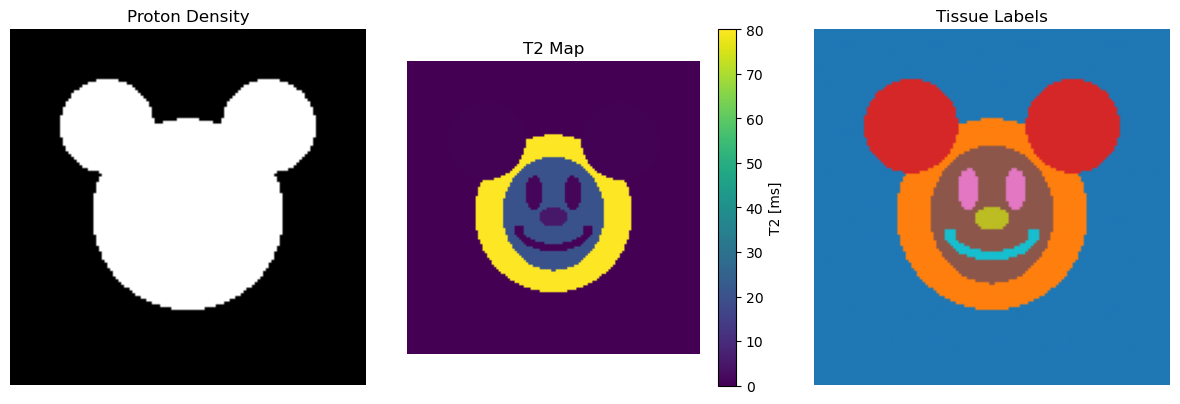

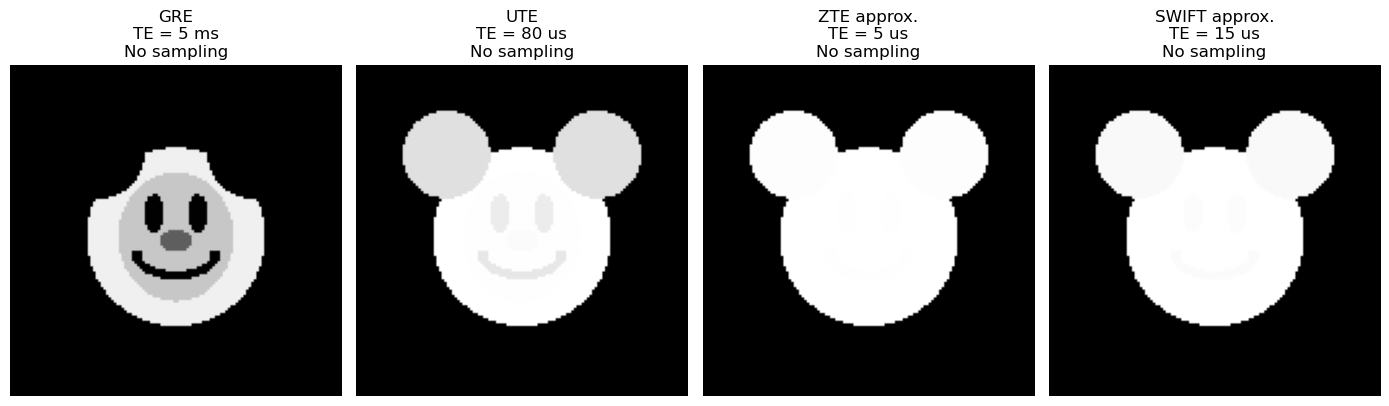

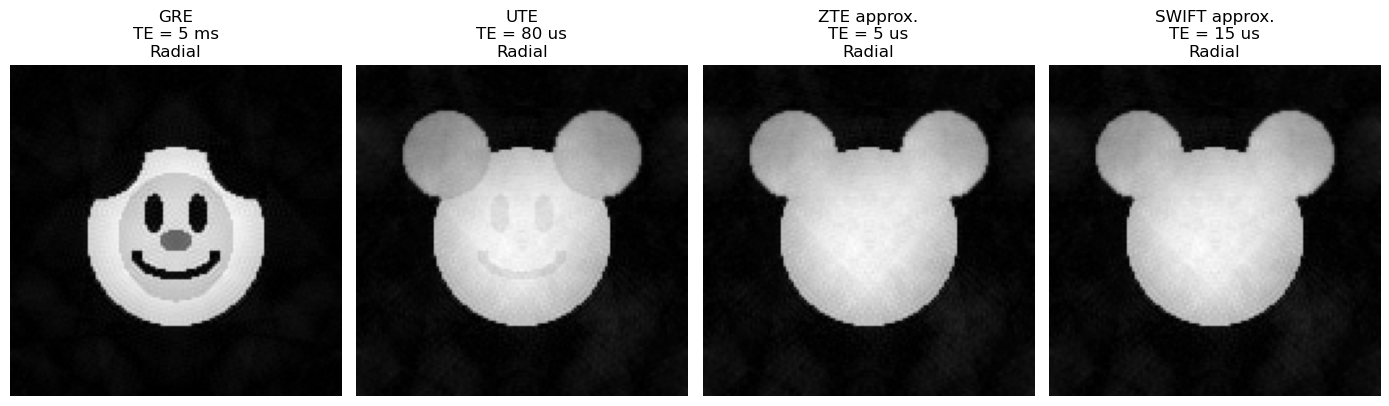

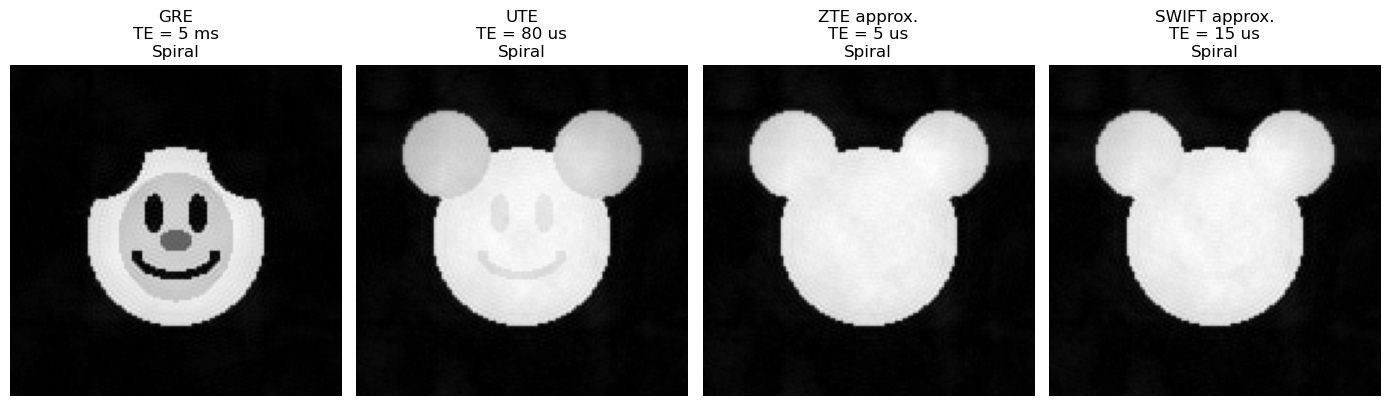

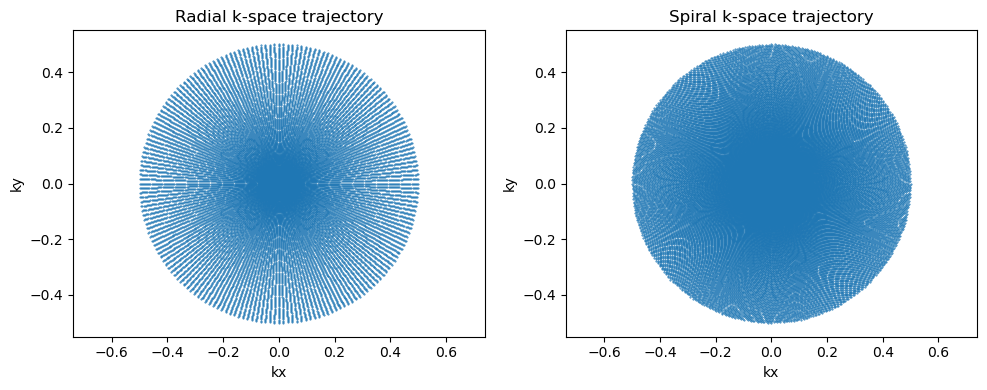

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata


# -----------------------------
# 1. Mickey Mouse T2 phantom
# -----------------------------
def make_mickey_t2_phantom(
    N=128,
    T2_head=80e-3,
    T2_ears=0.6e-3,
    T2_face=20e-3,
    T2_eyes=1.0e-3,
    T2_nose=5.0e-3,
    T2_mouth=0.8e-3,
):
    y, x = np.mgrid[1.2:-1.2:complex(N), -1.2:1.2:complex(N)]

    rho = np.zeros((N, N))
    T2 = np.zeros((N, N))
    labels = np.zeros((N, N))

    # Head
    head = x**2 + (y + 0.05)**2 <= 0.65**2
    rho[head] = 1.0
    T2[head] = T2_head
    labels[head] = 1

    # Ears
    left_ear = (x + 0.55)**2 + (y - 0.55)**2 <= 0.32**2
    right_ear = (x - 0.55)**2 + (y - 0.55)**2 <= 0.32**2
    ears = left_ear | right_ear
    rho[ears] = 1.0
    T2[ears] = T2_ears
    labels[ears] = 2

    # Face oval
    face = (x / 0.42)**2 + ((y + 0.05) / 0.47)**2 <= 1
    rho[face] = 1.0
    T2[face] = T2_face
    labels[face] = 3

    # Eyes
    left_eye = ((x + 0.16) / 0.07)**2 + ((y - 0.12) / 0.14)**2 <= 1
    right_eye = ((x - 0.16) / 0.07)**2 + ((y - 0.12) / 0.14)**2 <= 1
    eyes = left_eye | right_eye
    rho[eyes] = 1.0
    T2[eyes] = T2_eyes
    labels[eyes] = 4

    # Nose
    nose = (x / 0.12)**2 + ((y + 0.08) / 0.08)**2 <= 1
    rho[nose] = 1.0
    T2[nose] = T2_nose
    labels[nose] = 5

    # Mouth
    mouth_outer = ((x / 0.32)**2 + ((y + 0.18) / 0.18)**2 <= 1) & (y < -0.16)
    mouth_inner = ((x / 0.25)**2 + ((y + 0.18) / 0.12)**2 <= 1) & (y < -0.16)
    mouth = mouth_outer & ~mouth_inner
    rho[mouth] = 1.0
    T2[mouth] = T2_mouth
    labels[mouth] = 6

    return rho, T2, labels


# -----------------------------
# 2. TE / T2 decay image
# -----------------------------
def simulate_TE_image(rho, T2, TE):
    img = np.zeros_like(rho)
    mask = T2 > 0
    img[mask] = rho[mask] * np.exp(-TE / T2[mask])
    return img


# -----------------------------
# 3. Radial sampling + recon
# -----------------------------
def radial_sample_and_recon(img, n_spokes=192, n_samples=256): #n_spokes = 96
    N = img.shape[0]
    kspace = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))

    k = np.linspace(-0.5, 0.5, N, endpoint=False)
    KX, KY = np.meshgrid(k, k)

    angles = np.linspace(0, np.pi, n_spokes, endpoint=False)
    kr = np.linspace(-0.5, 0.5, n_samples)

    sample_kx = []
    sample_ky = []

    for theta in angles:
        sample_kx.append(kr * np.cos(theta))
        sample_ky.append(kr * np.sin(theta))

    sample_kx = np.concatenate(sample_kx)
    sample_ky = np.concatenate(sample_ky)

    samples = griddata(
        points=(KX.ravel(), KY.ravel()),
        values=kspace.ravel(),
        xi=(sample_kx, sample_ky),
        method="linear",
        fill_value=0
    )

    kspace_gridded = griddata(
        points=(sample_kx, sample_ky),
        values=samples,
        xi=(KX, KY),
        method="linear",
        fill_value=0
    )

    recon = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace_gridded)))
    recon = np.abs(recon)
    recon /= recon.max() + 1e-12

    return recon, sample_kx, sample_ky


# -----------------------------
# 4. Spiral sampling + recon
# -----------------------------
def spiral_sample_and_recon(img, n_interleaves=24, n_samples=2048, n_turns=8):
    N = img.shape[0]
    kspace = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))

    k = np.linspace(-0.5, 0.5, N, endpoint=False)
    KX, KY = np.meshgrid(k, k)

    t = np.linspace(0, 1, n_samples)
    r = 0.5 * t
    theta = 2 * np.pi * n_turns * t

    sample_kx = []
    sample_ky = []

    for i in range(n_interleaves):
        offset = 2 * np.pi * i / n_interleaves
        sample_kx.append(r * np.cos(theta + offset))
        sample_ky.append(r * np.sin(theta + offset))

    sample_kx = np.concatenate(sample_kx)
    sample_ky = np.concatenate(sample_ky)

    samples = griddata(
        points=(KX.ravel(), KY.ravel()),
        values=kspace.ravel(),
        xi=(sample_kx, sample_ky),
        method="linear",
        fill_value=0
    )

    kspace_gridded = griddata(
        points=(sample_kx, sample_ky),
        values=samples,
        xi=(KX, KY),
        method="linear",
        fill_value=0
    )

    recon = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace_gridded)))
    recon = np.abs(recon)
    recon /= recon.max() + 1e-12

    return recon, sample_kx, sample_ky


# -----------------------------
# 5. Create Mickey phantom
# -----------------------------
rho, T2, labels = make_mickey_t2_phantom(
    N=128,
    T2_head=80e-3,
    T2_ears=0.6e-3,
    T2_face=20e-3,
    T2_eyes=1.0e-3,
    T2_nose=5.0e-3,
    T2_mouth=0.8e-3,
)


# -----------------------------
# 6. Simulate methods
# -----------------------------
methods = {
    "GRE\nTE = 5 ms": 5e-3,
    "UTE\nTE = 80 us": 80e-6,
    "ZTE approx.\nTE = 5 us": 5e-6,
    "SWIFT approx.\nTE = 15 us": 15e-6,
}

image_results = {}
radial_results = {}
spiral_results = {}

for name, TE in methods.items():
    img = simulate_TE_image(rho, T2, TE)
    image_results[name] = img

    radial_recon, radial_kx, radial_ky = radial_sample_and_recon(
        img,
        n_spokes=96,
        n_samples=256
    )

    spiral_recon, spiral_kx, spiral_ky = spiral_sample_and_recon(
        img,
        n_interleaves=24,
        n_samples=2048,
        n_turns=8
    )

    radial_results[name] = radial_recon
    spiral_results[name] = spiral_recon


# -----------------------------
# 7. Plot phantom maps
# -----------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rho, cmap="gray")
plt.title("Proton Density")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(T2 * 1e3, cmap="viridis")
plt.colorbar(label="T2 [ms]")
plt.title("T2 Map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(labels, cmap="tab10")
plt.title("Tissue Labels")
plt.axis("off")

plt.tight_layout()
plt.show()


# -----------------------------
# 8. Plot direct TE images
# -----------------------------
plt.figure(figsize=(14, 4))

for i, (name, img) in enumerate(image_results.items(), start=1):
    plt.subplot(1, 4, i)
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title(name + "\nNo sampling")
    plt.axis("off")

plt.tight_layout()
plt.show()


# -----------------------------
# 9. Plot radial recon
# -----------------------------
plt.figure(figsize=(14, 4))

for i, (name, img) in enumerate(radial_results.items(), start=1):
    plt.subplot(1, 4, i)
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title(name + "\nRadial")
    plt.axis("off")

plt.tight_layout()
plt.show()


# -----------------------------
# 10. Plot spiral recon
# -----------------------------
plt.figure(figsize=(14, 4))

for i, (name, img) in enumerate(spiral_results.items(), start=1):
    plt.subplot(1, 4, i)
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title(name + "\nSpiral")
    plt.axis("off")

plt.tight_layout()
plt.show()


# -----------------------------
# 11. Plot trajectories
# -----------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(radial_kx, radial_ky, s=0.2)
plt.title("Radial k-space trajectory")
plt.xlabel("kx")
plt.ylabel("ky")
plt.axis("equal")

plt.subplot(1, 2, 2)
plt.scatter(spiral_kx, spiral_ky, s=0.2)
plt.title("Spiral k-space trajectory")
plt.xlabel("kx")
plt.ylabel("ky")
plt.axis("equal")

plt.tight_layout()
plt.show()